In [ ]:
import torch
from torchvision import datasets, transforms


root = "./data"
img_size = 64
batch_size = 128
num_workers = 2


transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(img_size, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),])

train_dataset = datasets.CelebA(
    root=root, split="train", download=True, transform=transform)

val_dataset = datasets.CelebA(
    root=root, split="valid", download=True, transform=transform)
test_dataset = datasets.CelebA(
    root=root, split="test", download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import zipfile
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path

zip_path = "/content/drive/MyDrive/img_align_celeba.zip"
extract_dir = "/content/celeba"
img_size  = 64
batch_size = 64
num_workers = 2
os.makedirs(extract_dir, exist_ok=True)


def _has_any_image(root: Path) -> bool:
    exts = ("*.jpg", "*.jpeg", "*.png")
    for ext in exts:
        if any(root.rglob(ext)):
            return True
    return False

if not _has_any_image(Path(extract_dir)):
    assert os.path.exists(zip_path), f"No encuentro el zip en {zip_path}"
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)

exts = ("*.jpg", "*.jpeg", "*.png")
all_paths = []
for ext in exts:
    all_paths += list(Path(extract_dir).rglob(ext))

if not all_paths:
    raise FileNotFoundError(
        f"No encontré imágenes (.jpg/.jpeg/.png) tras extraer {zip_path}.\n"
        f"Revisa manualmente el contenido de {extract_dir}.")

class FlatImageDataset(Dataset):
    def __init__(self, paths, transform=None, skip_broken=True):
        self.paths = sorted(map(str, paths))
        self.transform = transform
        self.skip_broken = skip_broken

        if len(self.paths) == 0:
            raise FileNotFoundError("La lista de imágenes está vacía.")

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            if self.skip_broken:
                return self.__getitem__((idx + 1) % len(self))
            else:
                raise e
        if self.transform:
            img = self.transform(img)
        return img, 0

transform = transforms.Compose([
    transforms.Resize(178, antialias=True),
    transforms.CenterCrop(178),
    transforms.Resize(img_size, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),])

dataset = FlatImageDataset(all_paths, transform=transform)
train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True)

print(f"[OK] Imágenes detectadas (recursivo): {len(dataset)}")
print(f"[OK] DataLoader listo: batch_size={batch_size}, img_size={img_size}")

[OK] Imágenes detectadas (recursivo): 202599
[OK] DataLoader listo: batch_size=64, img_size=64


In [3]:
imgs, _ = next(iter(train_loader))
imgs.shape

torch.Size([64, 3, 64, 64])

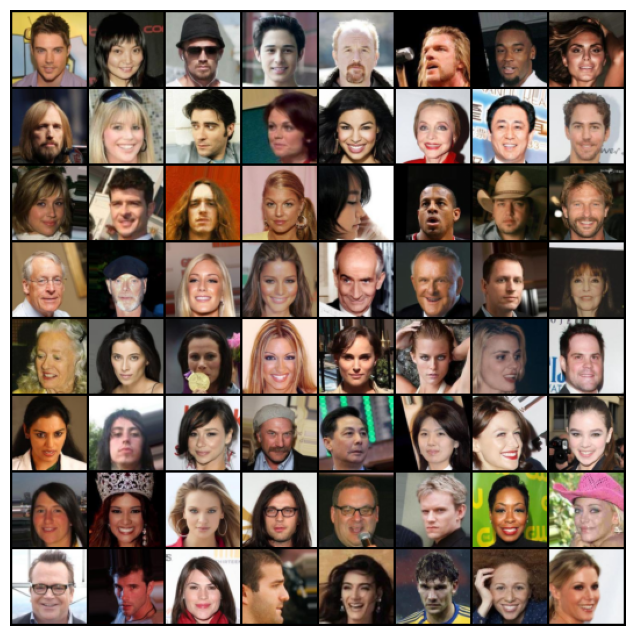

In [4]:
import matplotlib.pyplot as plt
import torchvision

imgs, _ = next(iter(train_loader))
imgs = (imgs * 0.5) + 0.5
grid = torchvision.utils.make_grid(imgs[:64], nrow=8)

plt.figure(figsize=(8,8))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.show()

# **Model**

## Discriminador tipo Resnet con std batch

In [5]:
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm as SN


def maybe_sn(module: nn.Module, use_sn: bool):
    return SN(module) if use_sn else module

class MinibatchStdDev(nn.Module):
    """
    Capa que incentiva la diversidad en los outputs de la red añadiendo un canal
    con la desviación estándar del minibatch.

    Idea central:
    - Si todas las muestras generadas son muy parecidas, la desviación estándar
      entre ellas será pequeña.
    - Al incluir explícitamente esta métrica como un canal extra en el tensor
      de activaciones, el discriminador aprende a detectar falta de diversidad.
    - Esto fuerza al generador a producir outputs más variados para engañarlo.

    Funcionamiento:
    1. Divide el batch en grupos (group_size).
    2. Calcula la desviación estándar por grupo sobre todos los canales y píxeles.
    3. Promedia esa desviación para obtener un único valor escalar por grupo.
    4. Replica ese valor en forma de un mapa 2D y lo concatena como un canal extra.
    5. Así, cada muestra lleva información de cuánta variabilidad hay entre las imágenes.
    """
    def __init__(self, group_size=32, eps=1e-8):
        super().__init__()
        self.group_size = group_size
        self.eps = eps

    def forward(self, x):
        B, C, H, W = x.shape
        g = min(self.group_size, B)
        if B % g != 0:
            g = B
        if g > 1:
            y = x.view(g, -1, C, H, W)
            y = y - y.mean(dim=0, keepdim=True)
            y = torch.sqrt(y.pow(2).mean(dim=0) + self.eps)
            y = y.mean(dim=(1, 2, 3), keepdim=True)
            y = y.repeat(g, 1, H, W)
            return torch.cat([x, y], dim=1)
        else:
            y = x.new_zeros(B, 1, H, W)
            return torch.cat([x, y], dim=1)

class ResDownBlock(nn.Module):
    """
    Bloque residual con reducción de resolución (downsampling).

    Propósito:
    - Reducir la resolución espacial (H, W) a la mitad mientras se transforman
      las características.
    - Mantener un camino residual (skip) para estabilizar el entrenamiento
      y facilitar el flujo del gradiente.
    - Similar a los bloques residuales de ResNet, pero incorporando un downsample.

    Estructura:
    - Rama principal (main path):
        Conv 3x3 -> LeakyReLU -> Conv 3x3 -> AvgPool(2x2)
    - Rama de atajo (skip path):
        Conv 1x1 -> AvgPool(2x2)
    - Se suman ambas ramas y se aplica una activación final.

    """
    def __init__(self, in_ch, out_ch, use_sn: bool):
        super().__init__()
        self.conv1 = maybe_sn(nn.Conv2d(in_ch, in_ch, 3, padding=1), use_sn)
        self.conv2 = maybe_sn(nn.Conv2d(in_ch, out_ch, 3, padding=1), use_sn)
        self.skip  = maybe_sn(nn.Conv2d(in_ch, out_ch, 1), use_sn)
        self.act   = nn.LeakyReLU(0.2, inplace=True)
        self.down  = nn.AvgPool2d(2)

        # Inits para LeakyReLU (SN no las “rompe”; sigue siendo útil)
        for m in [self.conv1, self.conv2, self.skip]:
            nn.init.kaiming_normal_(m.weight, a=0.2, nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x):
        y = self.act(self.conv1(x))
        y = self.conv2(y)
        y = self.down(y)
        s = self.down(self.skip(x))
        return self.act((y + s) / math.sqrt(2))

class Discriminator64(nn.Module):
    """
    Discriminador estilo StyleGAN para 64×64:
    - FromRGB 3x3 -> pila de ResDownBlocks (64→32→16→8→4)
    - MinibatchStdDev
    - Conv final + Linear a logit escalar
    """
    def __init__(self, base_ch=64, max_ch=512, in_channels=3, use_sn: bool=True):
        super().__init__()
        C1 = base_ch
        C2 = min(base_ch * 2, max_ch)
        C3 = min(base_ch * 4, max_ch)
        C4 = min(base_ch * 8, max_ch)

        # FromRGB
        self.from_rgb = maybe_sn(nn.Conv2d(in_channels, C1, 3, padding=1), use_sn)

        # Bloques residuales con SN opcional
        self.b64 = ResDownBlock(C1, C2, use_sn)
        self.b32 = ResDownBlock(C2, C3, use_sn)
        self.b16 = ResDownBlock(C3, C4, use_sn)
        self.b08 = ResDownBlock(C4, C4, use_sn)

        self.mbstd = MinibatchStdDev(group_size=32)

        # Conv final tras mbstd (+1 canal)
        self.conv_final = maybe_sn(nn.Conv2d(C4 + 1, C4, 3, padding=1), use_sn)
        self.act = nn.LeakyReLU(0.2, inplace=True)

        # Head: GAP → Linear
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = maybe_sn(nn.Linear(C4, 1), use_sn)

        # Inicializaciones
        nn.init.kaiming_normal_(self.from_rgb.weight, a=0.2, nonlinearity='leaky_relu')
        if self.from_rgb.bias is not None: nn.init.zeros_(self.from_rgb.bias)

        nn.init.kaiming_normal_(self.conv_final.weight, a=0.2, nonlinearity='leaky_relu')
        if self.conv_final.bias is not None: nn.init.zeros_(self.conv_final.bias)

        # Con SN en Linear, una init pequeña es suficiente
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.02)
        if self.fc.bias is not None: nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        y = self.act(self.from_rgb(x))   # [B, C1, 64, 64]
        y = self.b64(y)                  # [B, C2, 32, 32]
        y = self.b32(y)                  # [B, C3, 16, 16]
        y = self.b16(y)                  # [B, C4,  8,  8]
        y = self.b08(y)                  # [B, C4,  4,  4]

        y = self.mbstd(y)                # [B, C4+1, 4, 4]
        y = self.act(self.conv_final(y)) # [B, C4,   4,  4]
        y = self.gap(y).view(y.size(0), -1)  # [B, C4]
        logit = self.fc(y)               # [B, 1]
        return logit

## Generador

In [6]:
import math

class PixelNorm(nn.Module):
    """
    Normalización por píxel (Pixel-wise feature vector normalization).

    Propósito:
    - Escalar cada vector de características (en cada posición espacial)
      a una norma similar, reduciendo variaciones de escala.
    - Evita que ciertos canales dominen por magnitudes grandes.
    - Fue introducida en ProGAN y se usa principalmente sobre el vector
      latente `z`, no tanto en capas profundas.

    Funcionamiento:
    - Para cada muestra y cada posición espacial (pixel),
      calcula la media de los cuadrados de los valores en los canales.
    - Divide (normaliza) el vector de canales por la raíz cuadrada de esa media.
    - Así, cada vector de características en cada pixel queda con una magnitud
      (norma) aproximadamente constante.
    """
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(dim=1, keepdim=True) + self.eps)

class EqualLinear(nn.Module):
    """
    Capa lineal con *Equalized Learning Rate* (Equalized LR).

    Propósito:
    - Estabilizar el entrenamiento de GANs controlando explícitamente
      la escala de los pesos y del bias durante el forward.
    - Introducido en *Progressive Growing of GANs* (Karras et al., 2017).
    - Alternativa a normalizaciones como BatchNorm, pero diseñada
      específicamente para generadores/discriminadores.

    Funcionamiento:
    - Los pesos se inicializan como N(0,1).
    - En el forward se reescala dinámicamente por:
          (lr_mul / sqrt(in_dim))
      lo que controla la varianza de las activaciones.
    - El bias también se escala por `lr_mul`.
    - Esto desacopla la inicialización y la tasa de aprendizaje efectiva:
      se puede usar un `lr_mul` mayor/menor sin modificar el optimizador.
    """

    def __init__(self, in_dim, out_dim, lr_mul=1.0, bias=True):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_dim, in_dim))
        self.lr_mul = lr_mul
        self.scale = (1.0 / math.sqrt(in_dim)) * lr_mul

        if bias:
            self.bias = nn.Parameter(torch.zeros(out_dim))
        else:
            self.bias = None

    def forward(self, x):
        if self.bias is not None:
            bias = self.bias * self.lr_mul
        else:
            bias = None

        return F.linear(x, self.weight * self.scale, bias) # y=xA^t + b


class MappingNetwork(nn.Module):
    """
    z -> w
    - dims: 512
    - n_layers: 8 por defecto (paper)
    - activación: LeakyReLU(0.2)
    - sin BatchNorm
    - Equalized LR con lr_mul=0.01 (convención StyleGAN)
    - PixelNorm opcional en z
    """
    def __init__(self, z_dim=512, w_dim=512, n_layers=8, use_pixelnorm=True, lr_mul=0.01):
        super().__init__()
        self.use_pixelnorm = use_pixelnorm

        if use_pixelnorm:
            self.pn = PixelNorm()

        layers = []
        in_dim = z_dim
        for i in range(n_layers):
            layers.append(EqualLinear(in_dim, w_dim, lr_mul=lr_mul))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_dim = w_dim

        # Quitar la activación de la última
        layers = layers[:-1] + []
        self.net = nn.Sequential(*layers)

        # Media móvil de w
        self.register_buffer("w_avg", torch.zeros(w_dim))

    @torch.no_grad()
    def update_w_avg(self, w, beta=0.995):
        batch_avg = w.mean(dim=0)
        self.w_avg.lerp_(batch_avg, 1.0 - beta)

    def forward(self, z, update_avg=False):
        if self.use_pixelnorm:
            z = self.pn(z)

        # Forward
        w = self.net(z)

        if update_avg and self.training:
            self.update_w_avg(w)

        return w

In [7]:
class EqualConv2d(nn.Module):
    """
    Convolución con *Equalized Learning Rate* (Equalized LR).

    Propósito:
    - Estabilizar el entrenamiento en GANs ajustando la escala efectiva
      de los pesos durante el forward.
    - Fue introducida en *Progressive Growing of GANs* (Karras et al., 2017),
      junto con EqualLinear, como alternativa a normalizaciones como BatchNorm.

    Funcionamiento:
    - Inicializa los pesos con distribución N(0,1).
    - En el forward, los pesos se reescalan dinámicamente por:
          (lr_mul / sqrt(in_ch * kernel^2))
      lo cual mantiene controlada la varianza de las activaciones.
    - El bias, si existe, también se escala por `lr_mul`.
    - Esto permite separar la inicialización del control de la tasa de
      aprendizaje efectiva, facilitando la estabilidad sin necesidad
      de capas de normalización adicionales.

    Beneficio:
    - Ayuda a que la magnitud de las activaciones no dependa de la
      dimensionalidad de entrada ni del tamaño del kernel.
    """

    def __init__(self, in_ch, out_ch, kernel, stride=1, padding=0, lr_mul=1.0, bias=True):
        super().__init__()
        weight = torch.randn(out_ch, in_ch, kernel, kernel)
        self.weight = nn.Parameter(weight)
        self.lr_mul = lr_mul
        self.scale = (lr_mul / math.sqrt(in_ch * (kernel * kernel)))
        self.stride = stride
        self.padding = padding
        self.bias = nn.Parameter(torch.zeros(out_ch)) if bias else None

    def forward(self, x):
        w = self.weight * self.scale
        b = self.bias * self.lr_mul if self.bias is not None else None
        return F.conv2d(x, w, b, stride=self.stride, padding=self.padding)


class NoiseInjection(nn.Module):
    """
    Capa de inyección de ruido en mapas de características.

    Propósito:
    - Introducir variaciones estocásticas locales en las imágenes generadas,
      permitiendo que el generador aprenda a modelar detalles finos (textura,
      arrugas, pelo, imperfecciones) sin que estén codificados directamente
      en el vector latente `z`.
    """

    def __init__(self, channels):
        super().__init__()
        self.weight = nn.Parameter(torch.zeros(channels))

    def forward(self, x, noise=None):
        if noise is None:
            noise = torch.randn(x.size(0), 1, x.size(2), x.size(3), device=x.device, dtype=x.dtype)
        return x + self.weight.view(1, -1, 1, 1) * noise


class Blur2d(nn.Module):
    """
    Filtro de desenfoque 2D separable (Gaussian-like) usado comúnmente en GANs
    para estabilizar el entrenamiento al suavizar aliasing en imágenes.

    Args:
        kernel (tuple): Coeficientes del filtro 1D. Por defecto (1, 3, 3, 1).
        pad (tuple): Padding asimétrico (left, right, top, bottom), típicamente (1, 2, 1, 2).

    Atributos:
        weight (Tensor): Kernel 2D normalizado, registrado como buffer (no entrenable).
        pad (tuple): Especifica el padding reflejado aplicado antes de la convolución.

    Forward:
        Aplica padding reflejado y luego convolución por canal (groups=C)
        para suavizar la entrada sin alterar el número de canales.

    Output:
        Tensor con el mismo tamaño espacial que la entrada, pero con bordes suavizados.
    """
    def __init__(self, kernel=(1,3,3,1), pad=(1,2,1,2)):
        super().__init__()
        k = torch.tensor(kernel, dtype=torch.float32)
        k2d = (k[:, None] * k[None, :])          # kernel 2D separable
        k2d /= k2d.sum()                         # normalización
        self.register_buffer("weight", k2d[None, None, :, :])
        self.pad = pad                           # padding asimétrico

    def forward(self, x):
        B, C, H, W = x.shape
        w = self.weight.repeat(C, 1, 1, 1)
        x = F.pad(x, self.pad, mode="reflect")   # alternativa: "replicate"
        return F.conv2d(x, w, padding=0, groups=C)


class AffineStyle(nn.Module):
    """
    Proyección afín del vector latente intermedio w → [scale, bias].

    Propósito:
    - Traducir el vector latente `w` (dimensión 512 en StyleGAN) en parámetros
      de normalización adaptativa: una escala (γ) y un sesgo (β) por canal.
    - Estos parámetros controlan la modulación en *AdaIN*, permitiendo que
      el estilo global de la imagen (colores, texturas, rasgos) dependa
      directamente de `w`.
    - Esto genera el yb yc que se usa en AdaIn

    Funcionamiento:
    - Capa lineal (EqualLinear) que mapea w ∈ R^w_dim → R^(2*C).
      Los primeros C valores corresponden a escalas (γ),
      los siguientes C a sesgos (β).
    - Inicialización especial:
        • bias de la mitad "escala" inicializado en 1.0 (para que empiece
          como una identidad: γ≈1).
        • bias de la mitad "sesgo" inicializado en 0.0 (β≈0).
      → Esto asegura que al inicio AdaIN no modifique demasiado la activación.

    Beneficio:
    - El generador puede controlar de forma precisa cómo se aplican los estilos
      capa por capa, combinando información global (w) con normalización local.
    """
    def __init__(self, w_dim, channels, lr_mul=1.0):
        super().__init__()
        self.fc = EqualLinear(w_dim, 2 * channels, lr_mul=lr_mul)
        nn.init.zeros_(self.fc.bias)
        with torch.no_grad():
            self.fc.bias[:channels].fill_(1.0)

    def forward(self, w):
        return self.fc(w)


class AdaIN(nn.Module):
    """
    Adaptive Instance Normalization (AdaIN).

    Propósito:
    - Combinar normalización de características con un control directo de estilo
      proveniente del vector latente `w`.
    - Introducido originalmente para transferencia de estilo (Huang & Belongie, 2017),
      adaptado en *StyleGAN* (Karras et al., 2019) para controlar estilos en el generador.

    Funcionamiento:
    1. Normalización:
       - Se aplica InstanceNorm (por canal y por muestra), es decir:
         restar la media y dividir por la desviación estándar de cada canal
         en cada imagen → elimina información de escala e iluminación.
    2. Estilo:
       - El vector latente intermedio `w` es proyectado por `AffineStyle`
         en dos vectores: `scale (γ)` y `bias (β)`, ambos de dimensión C.
    3. Reescalado:
       - El tensor normalizado se modula con estos parámetros:
         x' = γ * x_norm + β
       - Esto reinyecta control de estilo capa a capa.

    Beneficio:
    - Elimina la dependencia de BatchNorm/LayerNorm.
    - Permite que el estilo de cada capa dependa explícitamente de `w`,
      lo que otorga un control jerárquico sobre la imagen generada
      (colores en capas bajas, formas globales en capas altas).
    """

    def __init__(self, channels, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.channels = channels

    def forward(self, x, style):
        B, C, H, W = x.shape
        assert C == self.channels
        style = style.view(B, 2, C)    # [B,2,C]
        scale, bias = style[:, 0], style[:, 1]  # [B,C], [B,C]

        # InstanceNorm: normaliza por canal en cada imagen
        mean = x.mean(dim=(2,3), keepdim=True)
        var = x.var(dim=(2,3), unbiased=False, keepdim=True)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        # Aplicamos AdaIn
        x_styled = x_norm * scale.view(B, C, 1, 1) + bias.view(B, C, 1, 1)
        return x_styled


class StyledConv(nn.Module):
    """
    Bloque convolucional modulado al estilo StyleGAN.

    Propósito (visión de alto nivel):
    - Combinar tres ideas clave para controlar “forma + textura + estilo” por capa:
      1) Convolución con Equalized LR (estabilidad en la escala de activaciones).
      2) Ruido estocástico canal-específico (detalles finos locales).
      3) Modulación de estilo vía AdaIN con parámetros derivados de w (control global).
    - El orden Conv → Noise → Activación → AdaIN separa:
        • extracción de características (conv),
        • inyección de estocasticidad (noise),
        • no linealidad (LReLU),
        • y normalización/estilización (AdaIN con [γ, β] desde w).
      Así, la normalización actúa sobre activaciones ya “excitadas” por la no linealidad.

    Flujo:
    - (Opcional) Upsample por interpolación: duplica H y W antes de la conv.
    - EqualConv2d: extracción de features con escala controlada.
    - NoiseInjection: añade variación local per-pixel escalada por canal.
    - LeakyReLU: introduce no linealidad estable.
    - AffineStyle(w) → [scale, bias]; AdaIN normaliza por instancia y modula con [γ, β].
    """

    def __init__(self, in_ch, out_ch, kernel, w_dim, upsample=False):
        super().__init__()
        self.upsample = upsample
        self.blur = Blur2d((1,3,3,1)) if upsample else None
        self.conv = EqualConv2d(in_ch, out_ch, kernel, padding=kernel//2) # Convolución con Equalized LR (padding para mantener tamaño si no hay upsample)
        self.noise = NoiseInjection(out_ch)# Ruido estocástico (parámetro por canal que escala el ruido)
        self.affine = AffineStyle(w_dim, out_ch, lr_mul=1.0)  # Proyección afín del estilo w → [scale, bias] por canal yb yc
        self.adain = AdaIN(out_ch)  # Normalización adaptativa por instancia
        self.act = nn.LeakyReLU(0.2, inplace=True) # No linealidad estable

    def forward(self, x, w, noise=None):
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode='nearest')
            x = self.blur(x)

        x = self.conv(x)
        x = self.noise(x, noise=noise)
        x = self.act(x)
        x = self.adain(x, self.affine(w))
        return x

class ToRGB(nn.Module):
    """
    Capa de salida que convierte un mapa de características en una imagen RGB.

    Propósito:
    - Proyectar las activaciones de un bloque convolucional al espacio de imagen
      con 3 canales (R, G, B).
    - No aplica activación final como Tanh; devuelve logits (valores sin normalizar),
      lo que deja al discriminador aprender la escala correcta de intensidades.

    Funcionamiento:
    - Convolución 1x1 con Equalized LR que ajusta los canales internos a 3.
    - No cambia resolución (solo canales), actuando como una proyección lineal
      sobre el espacio de color.
    """
    def __init__(self, in_ch):
        super().__init__()
        self.conv = EqualConv2d(in_ch, 3, kernel=1, padding=0, lr_mul=0.1)

    def forward(self, x):
        return self.conv(x)


class ConstantInput(nn.Module):
    """Tensor aprendido 4x4xC, compartido por el batch."""
    def __init__(self, channels, size=4):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, channels, size, size))

    def forward(self, batch_size):
        return self.weight.repeat(batch_size, 1, 1, 1)


In [8]:
class SynthesisNetwork64(nn.Module):
    """
    StyleGAN v1-like (AdaIN) a 64x64.
    - Empieza en constante 4x4x512
    - Por resolución: 2 convs “styled” + upsample entre escalas
    - ToRGB al final (64x64)
    - Soporta style mixing: pasar w por capa [B, L, 512] o uno único [B, 512]
    """

    def __init__(self, w_dim=512, fmap_base=512, ch_schedule=(512, 512, 256, 128, 64)):
        """
        ch_schedule define canales por resolución:
        4x4 -> 8x8 -> 16x16 -> 32x32 -> 64x64
        """

        super().__init__()
        assert len(ch_schedule) == 5, "Para 64x64 se esperan 5 resoluciones."
        c4, c8, c16, c32, c64 = ch_schedule

        self.const = ConstantInput(c4, size=4)

        # 4x4 (dos convs, sin upsample en la primera)
        self.conv4_1 = StyledConv(c4, c4, 3, w_dim, upsample=False)
        self.conv4_2 = StyledConv(c4, c8, 3, w_dim, upsample=True)   # upsample hacia 8x8

        # 8x8
        self.conv8_1 = StyledConv(c8, c8, 3, w_dim, upsample=False)
        self.conv8_2 = StyledConv(c8, c16, 3, w_dim, upsample=True)  # → 16x16

        # 16x16
        self.conv16_1 = StyledConv(c16, c16, 3, w_dim, upsample=False)
        self.conv16_2 = StyledConv(c16, c32, 3, w_dim, upsample=True)  # → 32x32

        # 32x32
        self.conv32_1 = StyledConv(c32, c32, 3, w_dim, upsample=False)
        self.conv32_2 = StyledConv(c32, c64, 3, w_dim, upsample=True)  # → 64x64

        # 64x64
        self.conv64_1 = StyledConv(c64, c64, 3, w_dim, upsample=False)
        self.conv64_2 = StyledConv(c64, c64, 3, w_dim, upsample=False)

        self.to_rgb = ToRGB(c64)
        self.num_layers = 10


    def forward(self, w):
        """
        w: [B, 512]  -> usa el mismo estilo para todas las capas
           [B, L, 512] con L=self.num_layers -> style mixing por capa
        return: imagen [B, 3, 64, 64] (logits, sin tanh)
        """

        if w.dim() == 2:
          w = w.unsqueeze(1).repeat(1, self.num_layers, 1)  # brodcasting para tener L vectores w =  [B,L,512]
        else:
            assert w.size(1) == self.num_layers

        B = w.size(0)
        x = self.const(B)

        w_iter = iter(w.unbind(dim=1))  # genera 10 tensores [B,512], uno por capa

        # 4x4
        x = self.conv4_1(x, next(w_iter))
        x = self.conv4_2(x, next(w_iter))  # upsample→8

        # 8x8
        x = self.conv8_1(x, next(w_iter))
        x = self.conv8_2(x, next(w_iter))  # →16

        # 16x16
        x = self.conv16_1(x, next(w_iter))
        x = self.conv16_2(x, next(w_iter)) # →32

        # 32x32
        x = self.conv32_1(x, next(w_iter))
        x = self.conv32_2(x, next(w_iter)) # →64

        # 64x64
        x = self.conv64_1(x, next(w_iter))
        x = self.conv64_2(x, next(w_iter))

        return self.to_rgb(x)

In [9]:

class StyleGANGenerator64(nn.Module):
    """
    Generador StyleGAN v1 para 64x64 que encapsula:
    - MappingNetwork: z -> w
    - SynthesisNetwork64: w (o w por capa) -> imagen

    Soporta:
    - style mixing (probabilidad style_mixing_prob, corte aleatorio)
    - truncation trick (psi respecto a w_avg)
    """

    def __init__(self,z_dim=512,w_dim=512,
        n_mapping=8, fmap_base=512,
        ch_schedule=(512, 512, 256, 128, 64),
        lr_mul_mapping=0.01,    # mapping más lento
        use_pixelnorm=True,
        truncation_psi=1.0, # 1.0 = sin truncation
        truncation_layers=None   # si None, aplica a todas; si int, aplica a primeras L capas
    ):

        super().__init__()
        self.z_dim = z_dim
        self.w_dim = w_dim
        self.truncation_psi = truncation_psi
        self.truncation_layers = truncation_layers

        # Mapping z->w  con w_avg
        self.mapping = MappingNetwork(
            z_dim=z_dim, w_dim=w_dim, n_layers=n_mapping,
            use_pixelnorm=use_pixelnorm, lr_mul=lr_mul_mapping)

        # Synthesis 4→64 (10 capas "styled")
        self.synthesis = SynthesisNetwork64(
            w_dim=w_dim, fmap_base=fmap_base, ch_schedule=ch_schedule)

        self.num_layers = self.synthesis.num_layers  # 10 para 64×64

    @torch.no_grad()
    def _truncate(self, w_broadcast):
        """
        Aplica truncation trick: w' = w_avg + psi * (w - w_avg).
        - w_broadcast: [B, L, w_dim]
        - truncation_layers: si es int, solo afecta a las primeras L capas.
        """

        if self.truncation_psi >= 1.0:
            return w_broadcast
        w_avg = self.mapping.w_avg
        if self.truncation_layers is None:
            # todas las capas
            return w_avg + self.truncation_psi * (w_broadcast - w_avg)

        else:
            L = w_broadcast.size(1)
            Ltr = min(self.truncation_layers, L)
            w_out = w_broadcast.clone()
            w_out[:, :Ltr, :] = w_avg + self.truncation_psi * (w_broadcast[:, :Ltr, :] - w_avg)
            return w_out

    def forward(self,z,
        style_mixing_prob: float = 0.0,
        update_w_avg: bool = True, truncation: bool = False):

        """
        z: [B, z_dim] ~ N(0,1)
        style_mixing_prob: prob. de usar 2 estilos (z2) con corte aleatorio.
        update_w_avg: actualizar w_avg del mapping (True en train, False en eval)
        truncation: aplicar o no truncation_psi en el forward (solo inferencia)

        return: fake [B, 3, 64, 64] (logits, sin tanh)
        """
        B = z.size(0)
        device = z.device

        w1 = self.mapping(z, update_avg=update_w_avg)  # [B, w_dim]

        if style_mixing_prob > 0.0 and torch.rand(()) < style_mixing_prob:
            z2 = torch.randn(B, self.z_dim, device=device)
            w2 = self.mapping(z2, update_avg=False)
            cut = torch.randint(1, self.num_layers, (1,), device=device).item()
            w_broadcast = torch.stack([w1]*self.num_layers, dim=1)
            w_broadcast[:, cut:, :] = w2.unsqueeze(1).repeat(1, self.num_layers - cut, 1)
        else:
            # un solo estilo para todas las capas
            w_broadcast = w1.unsqueeze(1).repeat(1, self.num_layers, 1)  # [B,L,w_dim]

        if truncation:
            w_broadcast = self._truncate(w_broadcast)

        fake = self.synthesis(w_broadcast)  # [B,3,64,64]

        return fake

## Training

In [10]:
def loss_hinge_discriminator(d_real, d_fake):
    """
    Hinge loss para el discriminador (SNGAN/BigGAN-style).

    Idea:
    - Empuja a D(x) ≥ 1 para reales y D(G(z)) ≤ -1 para falsas.
    - Márgenes ±1 estabilizan y evitan saturación típica de BCE.
    d_real: logits de D(x)   -> (N,1)
    d_fake: logits de D(G(z)) -> (N,1)
    """
    loss_real = torch.mean(F.relu(1.0 - d_real)) # max(0, 1 - D(x))
    loss_fake = torch.mean(F.relu(1.0 + d_fake)) # max(0, 1 + D(G(z)))
    return loss_real + loss_fake

def loss_hinge_generator(d_fake):
    """
    Hinge loss para el generador.

    Idea:
    - G quiere que D(G(z)) sea grande (idealmente > 1).
    - Se implementa como L_G = -E[D(G(z))].
    """

    return -torch.mean(d_fake) # G quiere subir D(G(z))


def r1_penalty(d_out_real, real):
    """
    Penalización R1 en datos reales: E[ ||∂D/∂x||^2 ].

    Idea:
    - Regulariza la suavidad de D alrededor de la variedad de datos reales.
    - Mejora estabilidad (reduce oscilaciones/gradientes patológicos).

    Implementación:
    - Toma gradiente de la suma de logits reales wrt. la imagen real.
    - Cuadra y promedia la norma L2 por muestra.

    Tip práctico:
    - Es costoso; aplicar cada N pasos (e.g., 16) y escalar por N en la loss total
      para mantener el valor esperado (L = ... + 0.5 * gamma * r1 * N).
    """
    grad = torch.autograd.grad(
        outputs=d_out_real.sum(), inputs=real,
        create_graph=True, retain_graph=True, only_inputs=True)[0]
    grad = grad.reshape(grad.size(0), -1)
    return (grad.pow(2).sum(dim=1)).mean()



In [11]:
@torch.no_grad()
def update_ema(ema_model, model, decay=0.999):
    """
    Ema = Exponential Moving Averege. Copiaos el generador y actualizamos sus pesos mediante
    un decay (parecido a Momentum pero no con gradientes con pesos). Esto se hace para que las imagenes
    que produce el generador sean mas suaves.
    """
    for (n_ema, p_ema), (n, p) in zip(ema_model.named_parameters(), model.named_parameters()):
        p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

    for (n_ema, b_ema), (n, b) in zip(ema_model.named_buffers(), model.named_buffers()):
        b_ema.copy_(b)


def diff_augment1(x, p=0.5, max_shift=1):
    """
    DiffAugment ligero:
      - Flip horizontal
      - Translación discreta sin wrap (relleno con 0)
      - Jitter multiplicativo de color (broadcast por batch)
    Supone imágenes en [-1, 1].
    """
    B, C, H, W = x.shape
    device = x.device

    #  Flip horizontal (por-batch)
    if torch.rand(1, device=device).item() < p:
        x = torch.flip(x, dims=[3])

    #  Translación sin wrap
    if torch.rand(1, device=device).item() < p and max_shift > 0:
        tx = int(torch.randint(-max_shift, max_shift + 1, (1,), device=device))
        ty = int(torch.randint(-max_shift, max_shift + 1, (1,), device=device))

        if tx != 0 or ty != 0:
            pad_left   = max(tx, 0)
            pad_right  = max(-tx, 0)
            pad_top    = max(ty, 0)
            pad_bottom = max(-ty, 0)
            x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), mode="constant", value=0.0)
            x = x[:, :, pad_top:pad_top+H, pad_left:pad_left+W]

    #  Jitter multiplicativo de color
    if torch.rand(1, device=device).item() < p:
        gain = 1.0 + 0.2 * torch.empty(B, 1, 1, 1, device=device).uniform_(-1, 1)
        x = (x * gain).clamp(-1, 1)

    return x


def diff_augment(x, p=0.5, max_shift=1):
    B, C, H, W = x.shape
    dev = x.device

    # Flip
    if torch.rand(1, device=dev).item() < p:
        x = torch.flip(x, dims=[3])

    # Translation (sin wrap, padding replicate)
    if torch.rand(1, device=dev).item() < p and max_shift > 0:
        tx = int(torch.randint(-max_shift, max_shift+1, (1,), device=dev))
        ty = int(torch.randint(-max_shift, max_shift+1, (1,), device=dev))
        if tx or ty:
            pad_left, pad_right  = max(tx,0), max(-tx,0)
            pad_top,  pad_bottom = max(ty,0), max(-ty,0)
            x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), mode="replicate")
            x = x[:, :, pad_top:pad_top+H, pad_left:pad_left+W]
    return x


def diff_augment2(x, p=0.5, max_shift=1, color_gain=0.05, assume='logits'):
    """
    assume: 'logits' -> no clamp; 'minus1_1' -> clamp a [-1,1] (si entrenaras en ese rango).
    """
    B, C, H, W = x.shape
    dev = x.device

    # Flip
    if torch.rand(1, device=dev).item() < p:
        x = torch.flip(x, dims=[3])

    # Translation (sin wrap)
    if torch.rand(1, device=dev).item() < p and max_shift > 0:
        tx = int(torch.randint(-max_shift, max_shift+1, (1,), device=dev))
        ty = int(torch.randint(-max_shift, max_shift+1, (1,), device=dev))
        if tx or ty:
            pad_left, pad_right  = max(tx,0), max(-tx,0)
            pad_top,  pad_bottom = max(ty,0), max(-ty,0)
            x = F.pad(x, (pad_left, pad_right, pad_top, pad_bottom), mode="replicate")
            x = x[:, :, pad_top:pad_top+H, pad_left:pad_left+W]

    # Color
    if color_gain and torch.rand(1, device=dev).item() < p:
        gain = 1.0 + color_gain * torch.empty(B, 1, 1, 1, device=dev).uniform_(-1, 1)
        x = x * gain
        if assume == 'minus1_1':
            x = x.clamp(-1, 1)

    return x


def make_unique_dir(base="samples"):
    if not os.path.exists(base):
        os.makedirs(base)
        return base

    i = 1
    while os.path.exists(f"{base}_{i}"):
        i += 1
    new_dir = f"{base}_{i}"
    os.makedirs(new_dir)
    return new_dir


## Visualization Utils

In [12]:
from contextlib import contextmanager

@contextmanager
def _eval_mode(module):
    was_training = module.training
    module.eval()
    try:
        yield
    finally:
        if was_training:
            module.train()

@torch.no_grad()
def _to_vis_range(x, assume_logits=True):
    if assume_logits:
        x = torch.tanh(x)
    return (x * 0.5 + 0.5).clamp(0, 1)

@torch.no_grad()
def sample_with_ema(G,
    gen_ema=None,
    z=None,
    z_dim=512,
    n=64,
    rows=8,
    seed=None,
    out_path=None,
    assume_logits=True,
    style_mixing_prob=0.0,
    truncation=None):
    device = next(G.parameters()).device
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    sampler = gen_ema if gen_ema is not None else G
    if z is None:
        z = torch.randn(n, z_dim, device=device)
    else:
        z = z.to(device)

    with _eval_mode(sampler):
        fake = sampler(
            z,
            style_mixing_prob=style_mixing_prob,
            update_w_avg=False,
            truncation=bool(truncation) if truncation is not None else False)
        vis = _to_vis_range(fake, assume_logits=assume_logits)

    if out_path is not None:
        dirname = os.path.dirname(out_path)
        if dirname != "":
            os.makedirs(dirname, exist_ok=True)
        vutils.save_image(vis, out_path, nrow=rows)

    return vis

@torch.no_grad()
def show_grid(imgs, rows=8, title=None):
    """Muestra una grilla en pantalla sin guardar."""
    grid = vutils.make_grid(imgs, nrow=rows)
    plt.figure(figsize=(6,6))
    if title:
      plt.title(title)
    plt.axis("off")
    plt.imshow(grid.detach().cpu().permute(1,2,0).numpy())
    plt.show()

In [61]:
# @title
import os, copy
import torch
import torch.nn.functional as F
from torch import nn
import numpy as np
import torchvision.utils as vutils
import matplotlib.pyplot as plt

@torch.no_grad()
def _to_vis_range(x):
    # Si tu G devuelve logits en [-inf,inf] y tú visualizas con tanh:
    x = torch.tanh(x)
    return (x * 0.5 + 0.5).clamp(0, 1)

def to_logits(x):
  """
  Convierte salidas del D a logits (B,1):
  - Si viene como mapa (B,1,H,W) o (B,C,H,W): GAP sobre H,W.
  - Si viene como (B,) o (B,1): lo re-forma a (B,1).
  """
  if x.dim() == 4:  # (B,C,H,W)
        x = x.mean(dim=(2, 3), keepdim=False)
        if x.size(1) != 1:
            x = x.mean(dim=1, keepdim=True)
        else:
            x = x.view(-1, 1)
        return x
  return x.view(-1, 1)

def train_gan(
    train_loader, generador, discriminador,
    optimizerG, optimizerD, criterion,
    latent_dim=512, epochs=20, gamma=10,
    fixed_z=None, smooth=False, smooth_advance=False,
    monitor_img=5, monitor_loss=2,
    train_gen=1, hinge=False,
    disc_steps=1,
    g_warmup_epochs=0,
    g_warmup_train_gen=2,
    use_ema=True, ema_decay=0.999,
    use_diffaug=True,
    r1_every=16, use_softplus=False, style_mixing_prob=0.0,
    ema_warmup=5,
    start_epoch=1,            # epoch absoluta inicial (para logging / warmups)
    base_global_step=0,       # step absoluto inicial (para R1 % r1_every)
    gen_ema=None, # pasa aquí tu EMA previa para no recrearla
):
    """
    Entrenamiento de (Style)GAN con Hinge o BCE/Softplus, R1, EMA y DiffAug.
    NUEVO:
      - start_epoch: para llevar conteo absoluto de épocas (logging, EMA warmup).
      - base_global_step: para que R1 no 'reinicie' su mod r1_every entre tandas.
      - gen_ema: pasa tu EMA previa para continuar suavización global.
    """


    if smooth and smooth_advance:
        raise ValueError('No se puede tener dos suavizamientos al tiempo')
    if hinge and (smooth or smooth_advance):
        raise ValueError('No se puede usar suavizado y hinge al mismo tiempo')
    if use_softplus and (criterion is not None):
        # criterion se ignora en modo softplus
        pass

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    generador.to(device).train()
    discriminador.to(device).train()

    #  EMA
    if use_ema:
        if gen_ema is None:
            gen_ema = copy.deepcopy(generador).to(device)
            gen_ema.eval()
            for p in gen_ema.parameters():
                p.requires_grad_(False)
    else:
        gen_ema = None

    #  fixed_z consistente entre tandas
    if fixed_z is None:
        fixed_z = torch.randn(64, latent_dim, device=device)

    save_dir = make_unique_dir("samples")
    os.makedirs(save_dir, exist_ok=True)

    # snapshot inicial (para comparar progreso)
    with torch.no_grad():
        sampler0 = generador if (not use_ema or start_epoch <= ema_warmup or gen_ema is None) else gen_ema
        fake0 = sampler0(fixed_z).detach()
        fake0_vis = _to_vis_range(fake0)
    vutils.save_image(fake0_vis, f"{save_dir}/epoch_{start_epoch-1:04d}.png", nrow=8)

    grid = vutils.make_grid(fake0_vis, nrow=8)
    plt.figure(figsize=(6,6)); plt.axis("off")
    plt.title("Fake samples (init) [G]")
    plt.imshow(grid.detach().cpu().permute(1,2,0).numpy())
    plt.show()

    history = {'loss_D': [], 'loss_G': []}
    global_step = int(base_global_step)

    #  loop de entrenamiento
    for e in range(epochs):
        absolute_epoch = start_epoch + e
        running_D = 0.0
        running_G = 0.0
        n_batches = 0

        g_steps_this_epoch = g_warmup_train_gen if absolute_epoch <= g_warmup_epochs else train_gen

        for real, _ in train_loader:
            b = real.size(0)
            real = real.to(device, non_blocking=True)

            # ========== Discriminador (disc_steps veces) ==========
            for _ in range(disc_steps):
                optimizerD.zero_grad(set_to_none=True)

                # Reales
                real_in = diff_augment(real) if use_diffaug else real
                out_real = to_logits(discriminador(real_in))

                # Falsas
                z = torch.randn(b, latent_dim, device=device)
                fake = generador(z, style_mixing_prob=0.0, update_w_avg=True, truncation=False).detach()
                fake = torch.tanh(fake)
                fake_in = diff_augment(fake) if use_diffaug else fake
                out_fake = to_logits(discriminador(fake_in))

                if hinge:
                    # Hinge
                    loss_D_core = loss_hinge_discriminator(out_real, out_fake)

                    # R1 SIN augment en reales
                    if (global_step % r1_every) == 0:
                        real_r1 = real.detach().requires_grad_(True)
                        out_real_r1 = to_logits(discriminador(real_r1))
                        r1 = r1_penalty(out_real_r1, real_r1)
                        loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                    else:
                        loss_D = loss_D_core

                else:
                    if use_softplus:
                        # No-saturante (StyleGAN-like)
                        loss_D_core = F.softplus(-out_real).mean() + F.softplus(out_fake).mean()
                        if (global_step % r1_every) == 0:
                            real_r1 = real.detach().requires_grad_(True)
                            out_real_r1 = to_logits(discriminador(real_r1))
                            r1 = r1_penalty(out_real_r1, real_r1)
                            loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                        else:
                            loss_D = loss_D_core
                    else:
                        # BCE con posibles suavizados (no recomendado con R1 moderno)
                        if smooth:
                            real_labels = torch.full((b, 1), 0.9, device=device, dtype=out_real.dtype)
                        elif smooth_advance:
                            real_labels = torch.empty(b, 1, device=device, dtype=out_real.dtype).uniform_(0.8, 1.0)
                        else:
                            real_labels = torch.ones(b, 1, device=device, dtype=out_real.dtype)
                        fake_labels = torch.zeros(b, 1, device=device, dtype=out_fake.dtype)
                        loss_D_real = criterion(out_real, real_labels)
                        loss_D_fake = criterion(out_fake, fake_labels)
                        loss_D_core = 0.5 * (loss_D_real + loss_D_fake)

                        if (global_step % r1_every) == 0:
                            real_r1 = real.detach().requires_grad_(True)
                            out_real_r1 = to_logits(discriminador(real_r1))
                            r1 = r1_penalty(out_real_r1, real_r1)
                            loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                        else:
                            loss_D = loss_D_core

                loss_D.backward()
                optimizerD.step()
                global_step += 1

            # ========== Generador (g_steps_this_epoch veces) ==========
            loss_G_total = 0.0
            for _ in range(g_steps_this_epoch):
                optimizerG.zero_grad(set_to_none=True)
                z = torch.randn(b, latent_dim, device=device)
                fake = generador(z, style_mixing_prob=style_mixing_prob, update_w_avg=True, truncation=False)
                fake = torch.tanh(fake)
                fake_in_for_G = diff_augment(fake) if use_diffaug else fake
                out_fake_for_G = to_logits(discriminador(fake_in_for_G))

                if hinge:
                    loss_G = loss_hinge_generator(out_fake_for_G)
                else:
                    if use_softplus:
                        loss_G = F.softplus(-out_fake_for_G).mean() # Softplus
                    else:
                        real_labels = torch.ones_like(out_fake_for_G, device=device, dtype=out_fake_for_G.dtype)
                        loss_G = criterion(out_fake_for_G, real_labels)

                loss_G.backward()
                optimizerG.step()
                loss_G_total += loss_G.item()

                # EMA update
                if use_ema and (gen_ema is not None):
                    # decay_t = min(ema_decay, 1 - 1.0/(global_step+1))  # opcional
                    update_ema(gen_ema, generador, decay=ema_decay)

            # métricas batch
            running_D += loss_D.item()
            running_G += (loss_G_total / max(1, g_steps_this_epoch))
            n_batches += 1

        # fin de época: logging y muestras
        epoch_loss_D = running_D / max(1, n_batches)
        epoch_loss_G = running_G / max(1, n_batches)
        history['loss_D'].append(epoch_loss_D)
        history['loss_G'].append(epoch_loss_G)

        if (absolute_epoch % monitor_loss) == 0:
            if hinge or use_softplus:
                with torch.no_grad():
                    d_real_m = out_real.mean().item()
                    d_fake_m = out_fake.mean().item()
            else:
                with torch.no_grad():
                    real_labels = torch.ones_like(out_real, device=device, dtype=out_real.dtype)
                    fake_labels = torch.zeros_like(out_fake, device=device, dtype=out_fake.dtype)
                    d_real_m = criterion(out_real, real_labels).item()
                    d_fake_m = criterion(out_fake, fake_labels).item()

            print(f"[Epoch {absolute_epoch:03d}] "
                  f"loss_D={epoch_loss_D:.4f} | loss_G={epoch_loss_G:.4f} | "
                  f"D(real)={d_real_m:.3f} | D(fake)={d_fake_m:.3f} | "
                  f"Dsteps={disc_steps} | Gsteps={g_steps_this_epoch}")

        if (absolute_epoch % monitor_img) == 0:
            with torch.no_grad():
                use_live_G = (absolute_epoch <= ema_warmup) or (not use_ema)
                sampler = generador if (use_live_G or gen_ema is None) else gen_ema
                fake = sampler(fixed_z).detach()
                fake_vis = _to_vis_range(fake)
            vutils.save_image(fake_vis, f"{save_dir}/epoch_{absolute_epoch:04d}.png", nrow=8)

    # Devuelve también fixed_z y global_step para facilitar checkpoint
    return history, gen_ema, fixed_z, global_step, (start_epoch + epochs - 1)


In [24]:
import os, time, copy, torch
import torch.nn.functional as F
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import time


def to_logits(x):
  """
  Convierte salidas del D a logits (B,1):
  - Si viene como mapa (B,1,H,W) o (B,C,H,W): GAP sobre H,W.
  - Si viene como (B,) o (B,1): lo re-forma a (B,1).
  """
  if x.dim() == 4:  # (B,C,H,W)
        x = x.mean(dim=(2, 3), keepdim=False)
        if x.size(1) != 1:
            x = x.mean(dim=1, keepdim=True)
        else:
            x = x.view(-1, 1)
        return x
  return x.view(-1, 1)


def tensor_mean_cpu(t):
    """
    Devuelve la media escalar del tensor `t` como float en CPU.
    Útil para registrar métricas sin mantener gradientes ni usar GPU.
    """
    return float(t.detach().mean().cpu())


def grad_norm(module):
    """
    Calcula la norma L2 total de todos los gradientes de un módulo PyTorch.
    Sirve para monitorear la magnitud del gradiente y detectar saturación o explosión.
    """
    total = 0.0
    for p in module.parameters():
        if p.grad is not None:
            g = p.grad.detach()
            total += (g.pow(2).sum()).item()
    return (total ** 0.5)


def param_norm(module):
    """
    Calcula la norma L2 de todos los parámetros del módulo.
    Permite evaluar la escala general de los pesos en entrenamiento.
    """
    total = 0.0
    for p in module.parameters():
        d = p.detach()
        total += (d.pow(2).sum()).item()
    return (total ** 0.5)


def sched_stylemix(epoch):
    """
    Scheduler del parámetro de style-mixing:
    - Epochs 1–2: bajo (0.1)
    - 3–6: incremento lineal (0.15 → 0.375)
    - 7+: estable (0.45)
    Controla la intensidad del mixing progresivamente.
    """
    if epoch <= 2:
        return 0.1
    if epoch <= 6:
        return 0.15 + 0.075*(epoch-3)
    return 0.45


def sched_lrd(history_D):
    """
    Ajusta dinámicamente el learning rate del discriminador.
    Si el D se vuelve demasiado dominante (promedio de aciertos < 0.40 en las últimas 3 iteraciones),
    reduce el lr en un 20%. Devuelve un multiplicador (0.8 o 1.0).
    """
    if len(history_D) >= 3 and sum(history_D[-3:])/3 < 0.40:
        return 0.8
    return 1.0


def train_gan(
    train_loader, generador, discriminador,
    optimizerG, optimizerD, criterion,
    latent_dim=512, epochs=20, gamma=10,
    fixed_z=None, smooth=False, smooth_advance=False,
    monitor_img=5, monitor_loss=2,
    train_gen=1, hinge=False,
    disc_steps=1,
    g_warmup_epochs=0,
    g_warmup_train_gen=2,
    use_ema=True, ema_decay=0.999,
    use_diffaug=True,
    r1_every=16, use_softplus=False, style_mixing_prob=0.0,
    ema_warmup=5,
    start_epoch=1,            # epoch absoluta inicial (para logging / warmups)
    base_global_step=0,       # step absoluto inicial (para R1 % r1_every)
    gen_ema=None, # pasa aquí tu EMA previa para no recrearla
    style_decay = False,
    lr_Disc_decay =False,
    control_noise = False , noise_clip_value = 0.5 # Valores para cliping de noise
):
    """
    Entrenamiento de (Style)GAN con Hinge o BCE/Softplus, R1, EMA y DiffAug:
      - start_epoch: para llevar conteo absoluto de épocas (logging, EMA warmup).
      - base_global_step: para que R1 no 'reinicie' su mod r1_every entre tandas.
      - gen_ema: pasa tu EMA previa para continuar suavización global.

    (Mejoras de logging y monitoreo sin costo relevante de GPU)
      - Promedios por época de D(real) y D(fake) (no solo el último batch).
      - Normas de gradiente de G y D (promedio por época, computadas tras backward).
      - Normas L2 de parámetros (||θ||) de G y D (cada época, baratas).
      - Tiempos por época y pasos procesados.
      - Historia extendida en 'history': loss_D, loss_G, D_real, D_fake,
        grad_norm_G, grad_norm_D, param_norm_G, param_norm_D, epoch_time_sec.
    """

    if smooth and smooth_advance:
        raise ValueError('No se puede tener dos suavizamientos al tiempo')
    if hinge and (smooth or smooth_advance):
        raise ValueError('No se puede usar suavizado y hinge al mismo tiempo')
    if use_softplus and (criterion is not None):
        # criterion se ignora en modo softplus
        pass

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    generador.to(device).train()
    discriminador.to(device).train()

    #  EMA
    if use_ema:
        if gen_ema is None:
            gen_ema = copy.deepcopy(generador).to(device)
            gen_ema.eval()
            for p in gen_ema.parameters():
                p.requires_grad_(False)
    else:
        gen_ema = None

    #  fixed_z consistente entre tandas
    if fixed_z is None:
        fixed_z = torch.randn(64, latent_dim, device=device)

    save_dir = make_unique_dir("samples")
    os.makedirs(save_dir, exist_ok=True)

    # snapshot inicial
    with torch.no_grad():
        sampler0 = generador if (not use_ema or gen_ema is None) else gen_ema
        fake0 = sampler0(fixed_z).detach()
        fake0_vis = _to_vis_range(fake0)
    vutils.save_image(fake0_vis, f"{save_dir}/epoch_{start_epoch-1:04d}.png", nrow=8)

    grid = vutils.make_grid(fake0_vis, nrow=8)
    plt.figure(figsize=(6,6)); plt.axis("off")
    plt.title("Fake samples (init) [G or G_EMA]")
    plt.imshow(grid.detach().cpu().permute(1,2,0).numpy())
    plt.show()

    # Historia
    history = {
        'loss_D': [], 'loss_G': [],
        'D_real': [], 'D_fake': [],
        'grad_norm_G': [], 'grad_norm_D': [],
        'param_norm_G': [], 'param_norm_D': [],
        'epoch_time_sec': [], 'steps_per_epoch': []}

    # Pequeña EMA para loss (suavizado visual de logs)
    def ema_update(old, new, alpha=0.98):
        return new if old is None else (alpha * old + (1 - alpha) * new)

    lossD_ema, lossG_ema = None, None


    global_step = int(base_global_step)

    #  loop de entrenamiento
    for e in range(epochs):
        t0 = time.time()
        absolute_epoch = start_epoch + e

        # Acumuladores por época
        running_D = 0.0
        running_G = 0.0
        n_batches = 0

        dreal_acc, dfake_acc, count_acc = 0.0, 0.0, 0
        gradG_acc, gradD_acc = 0.0, 0.0
        gradG_cnt, gradD_cnt = 0, 0

        g_steps_this_epoch = g_warmup_train_gen if absolute_epoch <= g_warmup_epochs else train_gen

        for real, _ in train_loader:
            b = real.size(0)
            real = real.to(device, non_blocking=True)

            # ========== Discriminador (disc_steps veces) ==========
            for _ in range(disc_steps):
                optimizerD.zero_grad(set_to_none=True)

                # Reales
                real_in = diff_augment(real) if use_diffaug else real
                out_real = to_logits(discriminador(real_in))

                # Falsas
                z = torch.randn(b, latent_dim, device=device)
                fake = generador(z, style_mixing_prob=0.0, update_w_avg=True, truncation=False).detach()
                fake_in = diff_augment(fake) if use_diffaug else fake
                out_fake = to_logits(discriminador(fake_in))

                if hinge:
                    # Hinge
                    loss_D_core = loss_hinge_discriminator(out_real, out_fake)

                    # R1 SIN augment en reales
                    if (global_step % r1_every) == 0:
                        real_r1 = real.detach().requires_grad_(True)
                        out_real_r1 = to_logits(discriminador(real_r1))
                        r1 = r1_penalty(out_real_r1, real_r1)
                        loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                    else:
                        loss_D = loss_D_core

                else:
                    if use_softplus:
                        # No-saturante (StyleGAN-like)
                        loss_D_core = F.softplus(-out_real).mean() + F.softplus(out_fake).mean()
                        if (global_step % r1_every) == 0:
                            real_r1 = real.detach().requires_grad_(True)
                            out_real_r1 = to_logits(discriminador(real_r1))
                            r1 = r1_penalty(out_real_r1, real_r1)
                            loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                        else:
                            loss_D = loss_D_core
                    else:
                        # BCE con posibles suavizados (no recomendado con R1 moderno)
                        if smooth:
                            real_labels = torch.full((b, 1), 0.9, device=device, dtype=out_real.dtype)
                        elif smooth_advance:
                            real_labels = torch.empty(b, 1, device=device, dtype=out_real.dtype).uniform_(0.8, 1.0)
                        else:
                            real_labels = torch.ones(b, 1, device=device, dtype=out_real.dtype)
                        fake_labels = torch.zeros(b, 1, device=device, dtype=out_fake.dtype)
                        loss_D_real = criterion(out_real, real_labels)
                        loss_D_fake = criterion(out_fake, fake_labels)
                        loss_D_core = 0.5 * (loss_D_real + loss_D_fake)

                        if (global_step % r1_every) == 0:
                            real_r1 = real.detach().requires_grad_(True)
                            out_real_r1 = to_logits(discriminador(real_r1))
                            r1 = r1_penalty(out_real_r1, real_r1)
                            loss_D = loss_D_core + 0.5 * gamma * r1 * r1_every
                        else:
                            loss_D = loss_D_core

                loss_D.backward()

                # Monitoreo ligero: norma de gradiente de D
                gnormD = grad_norm(discriminador)
                gradD_acc += gnormD; gradD_cnt += 1

                optimizerD.step()
                global_step += 1

                # Acumular promedios de D(real)/D(fake)
                with torch.no_grad():
                    dreal_acc += tensor_mean_cpu(out_real)
                    dfake_acc += tensor_mean_cpu(out_fake)
                    count_acc += 1

            # ========== Generador (g_steps_this_epoch veces) ==========
            loss_G_total = 0.0
            for _ in range(g_steps_this_epoch):
                optimizerG.zero_grad(set_to_none=True)
                z = torch.randn(b, latent_dim, device=device)

                style_mixing_prob_epoch = style_mixing_prob
                if style_decay:
                  style_mixing_prob_epoch = sched_stylemix(absolute_epoch)

                fake = generador(z, style_mixing_prob=style_mixing_prob_epoch, update_w_avg=True, truncation=False)
                fake_in_for_G = diff_augment(fake) if use_diffaug else fake
                out_fake_for_G = to_logits(discriminador(fake_in_for_G))

                if hinge:
                    loss_G = loss_hinge_generator(out_fake_for_G)
                else:
                    if use_softplus:
                        loss_G = F.softplus(-out_fake_for_G).mean() # Softplus
                    else:
                        real_labels = torch.ones_like(out_fake_for_G, device=device, dtype=out_fake_for_G.dtype)
                        loss_G = criterion(out_fake_for_G, real_labels)

                loss_G.backward()

                # Monitoreo ligero: norma de gradiente de G
                gnormG = grad_norm(generador)
                gradG_acc += gnormG; gradG_cnt += 1

                optimizerG.step()
                loss_G_total += loss_G.item()

                # EMA update
                if use_ema and (gen_ema is not None):
                    update_ema(gen_ema, generador, decay=ema_decay)

            # métricas batch (loss promediado por pasos de G)
            running_D += loss_D.item()
            running_G += (loss_G_total / max(1, g_steps_this_epoch))
            n_batches += 1

        #  fin de época: logging y muestras
        epoch_loss_D = running_D / max(1, n_batches)
        epoch_loss_G = running_G / max(1, n_batches)
        lossD_ema = ema_update(lossD_ema, epoch_loss_D)
        lossG_ema = ema_update(lossG_ema, epoch_loss_G)

        d_real_m = dreal_acc / max(1, count_acc)
        d_fake_m = dfake_acc / max(1, count_acc)
        gnormG_m = (gradG_acc / max(1, gradG_cnt))
        gnormD_m = (gradD_acc / max(1, gradD_cnt))

        pnormG = param_norm(generador)
        pnormD = param_norm(discriminador)

        epoch_time = time.time() - t0

        history['loss_D'].append(epoch_loss_D)
        history['loss_G'].append(epoch_loss_G)
        history['D_real'].append(d_real_m)
        history['D_fake'].append(d_fake_m)
        history['grad_norm_G'].append(gnormG_m)
        history['grad_norm_D'].append(gnormD_m)
        history['param_norm_G'].append(pnormG)
        history['param_norm_D'].append(pnormD)
        history['epoch_time_sec'].append(epoch_time)
        history['steps_per_epoch'].append(len(train_loader) * (disc_steps + g_steps_this_epoch))

        if (absolute_epoch % monitor_loss) == 0:
            print(
                f"[Epoch {absolute_epoch:03d}] "
                f"loss_D={epoch_loss_D:.4f} (EMA {lossD_ema:.4f}) | "
                f"loss_G={epoch_loss_G:.4f} (EMA {lossG_ema:.4f}) | "
                f"D(real)={d_real_m:.3f} | D(fake)={d_fake_m:.3f} | "
                f"||∇G||={gnormG_m:.3f} | ||∇D||={gnormD_m:.3f} | "
                f"||θ_G||={pnormG:.1f} | ||θ_D||={pnormD:.1f} | "
                f"batches={n_batches} | time={epoch_time:.1f}s")

        if control_noise:
          with torch.no_grad():
            for m in generador.modules():
              if isinstance(m, NoiseInjection) and hasattr(m, "weight"):
                  m.weight.clamp_(-noise_clip_value, noise_clip_value)

            if (use_ema and gen_ema is not None):
              for mn in gen_ema.modules():
                if isinstance(mn, NoiseInjection) and hasattr(mn, "weight"):
                   mn.weight.clamp_(-noise_clip_value, noise_clip_value)

        if (absolute_epoch % monitor_img) == 0:
            with torch.no_grad():
                use_live_G = (absolute_epoch <= ema_warmup) or (not use_ema) or (gen_ema is None)
                sampler = generador if use_live_G else gen_ema
                fake = sampler(fixed_z).detach()
                fake_vis = _to_vis_range(fake)
            vutils.save_image(fake_vis, f"{save_dir}/epoch_{absolute_epoch:04d}.png", nrow=8)

        if lr_Disc_decay:
          scale = sched_lrd(history['loss_D'])
          if scale < 1.0:
            for pg in optimizerD.param_groups:
                pg['lr'] *= scale
            print(f"[Epoch {absolute_epoch:03d}] ↓ lr_D x{scale:.2f} -> {optimizerD.param_groups[0]['lr']:.2e}")


    return history, gen_ema, fixed_z, global_step, (start_epoch + epochs - 1)

## Train Model

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = StyleGANGenerator64(
    z_dim=512, w_dim=512, n_mapping=8,
    ch_schedule=(512, 512, 256, 128, 64),
    truncation_psi=0.7,
    truncation_layers=8 ).to(device)

D = Discriminator64(base_ch=64, max_ch=512, in_channels=3).to(device)

lr_G = 1e-3
lr_D = 7e-4

optimizerG = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.0, 0.99))
optimizerD = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.0, 0.99))

criterion = nn.BCEWithLogitsLoss()


In [108]:
total_params = sum(p.numel() for p in G.parameters())
print(f"Total parámetros Generador: {total_params}")

Total parámetros Generador: 14112707


In [109]:
total_params = sum(p.numel() for p in D.parameters())
print(f"Total parámetros Discriminador: {total_params}")

Total parámetros Discriminador: 9845697


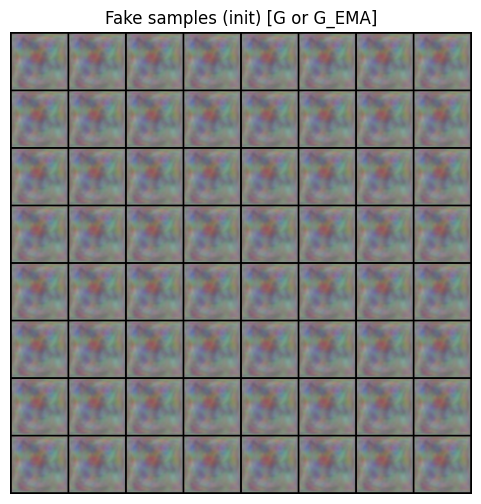

[Epoch 001] loss_D=1.2016 (EMA 1.2016) | loss_G=0.8533 (EMA 0.8533) | D(real)=0.696 | D(fake)=-0.755 | ||∇G||=0.524 | ||∇D||=4.184 | ||θ_G||=3771.7 | ||θ_D||=162.3 | batches=3166 | time=444.9s
[Epoch 002] loss_D=0.8070 (EMA 1.1937) | loss_G=1.1476 (EMA 0.8592) | D(real)=1.097 | D(fake)=-1.084 | ||∇G||=0.710 | ||∇D||=2.548 | ||θ_G||=3780.8 | ||θ_D||=219.8 | batches=3166 | time=445.6s
[Epoch 003] loss_D=0.6546 (EMA 1.1829) | loss_G=1.2437 (EMA 0.8669) | D(real)=1.264 | D(fake)=-1.196 | ||∇G||=0.748 | ||∇D||=2.044 | ||θ_G||=3788.9 | ||θ_D||=260.7 | batches=3166 | time=447.1s
[Epoch 004] loss_D=0.5884 (EMA 1.1710) | loss_G=1.3127 (EMA 0.8758) | D(real)=1.323 | D(fake)=-1.271 | ||∇G||=0.725 | ||∇D||=1.757 | ||θ_G||=3801.3 | ||θ_D||=295.5 | batches=3166 | time=444.3s
[Epoch 005] loss_D=0.5716 (EMA 1.1590) | loss_G=1.3637 (EMA 0.8856) | D(real)=1.306 | D(fake)=-1.327 | ||∇G||=0.754 | ||∇D||=1.629 | ||θ_G||=3811.0 | ||θ_D||=329.3 | batches=3166 | time=444.9s


In [129]:
history1, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader, # Datos
    generador=G, discriminador=D, # Redes G y D
    optimizerG=optimizerG, optimizerD=optimizerD, # Optimizadores para las redes
    criterion=criterion, # Criterio (si no se usa Hinge)
    latent_dim=512, epochs=5, gamma=16, # Epocas y R1 pennalty
    monitor_img=2, monitor_loss=1, # Moniterio
    train_gen=1, hinge=True, disc_steps=1, # Hinge y pasos de cada modelo
    g_warmup_epochs=0, g_warmup_train_gen=1, # Warmup para generador (por si acaso)
    use_ema=True, ema_decay=0.9995, # EMA
    use_diffaug=True,
    r1_every=16, use_softplus=False, # R1 y softplus
    style_mixing_prob=0.45, # StyleMixing (paper like)
    start_epoch=1,
    base_global_step=0,
    gen_ema=None # Para pasar ema despues
)

## Save Chekpoiont

In [131]:
ckpt1 = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt1, "stylegan64_celeba_pt1.pt")

## Load Chekpoin

In [ ]:
ckpt = torch.load("stylegan64_celeba_pt1.pt")

G.load_state_dict(ckpt["G"])
D.load_state_dict(ckpt["D"])
optimizerG.load_state_dict(ckpt["optG"])
optimizerD.load_state_dict(ckpt["optD"])

gen_ema = copy.deepcopy(G).to(device)
gen_ema.load_state_dict(ckpt["gen_ema"])
for p in gen_ema.parameters():
  p.requires_grad_(False)
gen_ema.eval()

fixed_z = ckpt["fixed_z"].to(device)
base_global_step = int(ckpt["global_step"])
start_epoch = int(ckpt["trained_epochs_total"]) + 1

## Continuar train

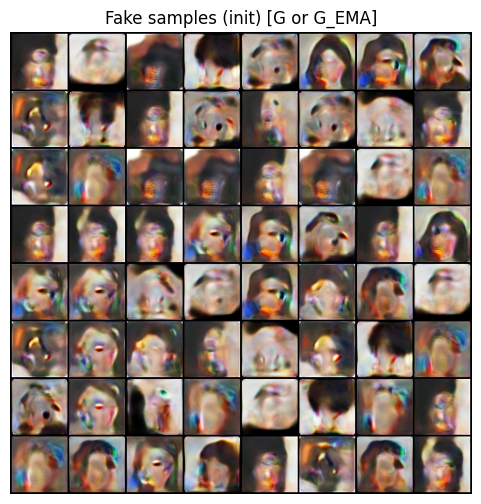

[Epoch 006] loss_D=0.5203 (EMA 0.5203) | loss_G=1.4282 (EMA 1.4282) | D(real)=1.416 | D(fake)=-1.393 | ||∇G||=0.775 | ||∇D||=1.504 | ||θ_G||=3820.6 | ||θ_D||=360.3 | batches=3166 | time=444.0s
[Epoch 006] ↓ lr_D x1.00 -> 7.00e-04
[Epoch 007] loss_D=0.5032 (EMA 0.5200) | loss_G=1.4652 (EMA 1.4289) | D(real)=1.421 | D(fake)=-1.430 | ||∇G||=0.760 | ||∇D||=1.433 | ||θ_G||=3830.5 | ||θ_D||=389.4 | batches=3166 | time=443.2s
[Epoch 007] ↓ lr_D x1.00 -> 7.00e-04
[Epoch 008] loss_D=0.4994 (EMA 0.5196) | loss_G=1.4861 (EMA 1.4301) | D(real)=1.426 | D(fake)=-1.454 | ||∇G||=0.740 | ||∇D||=1.369 | ||θ_G||=3839.3 | ||θ_D||=416.6 | batches=3166 | time=445.9s
[Epoch 008] ↓ lr_D x1.00 -> 7.00e-04
[Epoch 009] loss_D=0.4709 (EMA 0.5186) | loss_G=1.5072 (EMA 1.4316) | D(real)=1.465 | D(fake)=-1.482 | ||∇G||=0.719 | ||∇D||=1.316 | ||θ_G||=3849.5 | ||θ_D||=441.9 | batches=3166 | time=447.7s
[Epoch 009] ↓ lr_D x1.00 -> 7.00e-04
[Epoch 010] loss_D=0.4605 (EMA 0.5175) | loss_G=1.5267 (EMA 1.4335) | D(real)=1.

In [133]:
history2, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=10, gamma=14,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9995,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.0,
    start_epoch=6,                   # continúa desde 5+1
    base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=True, lr_Disc_decay=True
)

In [134]:
ckpt2 = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt2, "stylegan64_celeba_pt2.pt")



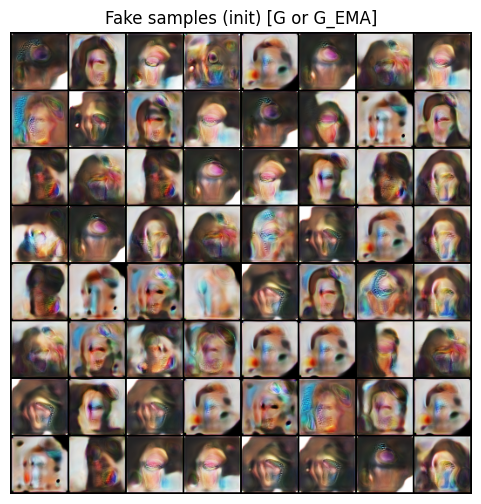

[Epoch 016] loss_D=0.4584 (EMA 0.4584) | loss_G=1.5080 (EMA 1.5080) | D(real)=1.402 | D(fake)=-1.483 | ||∇G||=0.603 | ||∇D||=1.216 | ||θ_G||=3921.2 | ||θ_D||=608.7 | batches=3166 | time=445.6s
[Epoch 017] loss_D=0.4621 (EMA 0.4585) | loss_G=1.5269 (EMA 1.5083) | D(real)=1.379 | D(fake)=-1.502 | ||∇G||=0.635 | ||∇D||=1.231 | ||θ_G||=3931.1 | ||θ_D||=628.9 | batches=3166 | time=443.6s
[Epoch 018] loss_D=0.4546 (EMA 0.4584) | loss_G=1.5237 (EMA 1.5086) | D(real)=1.396 | D(fake)=-1.499 | ||∇G||=0.652 | ||∇D||=1.225 | ||θ_G||=3944.4 | ||θ_D||=648.3 | batches=3166 | time=442.9s
[Epoch 019] loss_D=0.4651 (EMA 0.4585) | loss_G=1.5360 (EMA 1.5092) | D(real)=1.395 | D(fake)=-1.508 | ||∇G||=0.666 | ||∇D||=1.239 | ||θ_G||=3955.0 | ||θ_D||=667.2 | batches=3166 | time=443.0s
[Epoch 020] loss_D=0.4547 (EMA 0.4584) | loss_G=1.5487 (EMA 1.5100) | D(real)=1.397 | D(fake)=-1.522 | ||∇G||=0.692 | ||∇D||=1.253 | ||θ_G||=3966.6 | ||θ_D||=685.6 | batches=3166 | time=442.8s
[Epoch 021] loss_D=0.4504 (EMA 0.45

In [140]:
history3, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=10, gamma=20,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=2, g_warmup_train_gen=2,
    use_ema=True, ema_decay=0.9995,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.30,
    start_epoch=16,
    base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True
)

In [143]:
ckpt3 = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt3, "stylegan64_celeba_pt3.pt")

In [15]:
ckpt = torch.load("/content/stylegan 25 epocas.pt")

G.load_state_dict(ckpt["G"])
D.load_state_dict(ckpt["D"])
optimizerG.load_state_dict(ckpt["optG"])
optimizerD.load_state_dict(ckpt["optD"])

gen_ema = copy.deepcopy(G).to(device)
gen_ema.load_state_dict(ckpt["gen_ema"])
for p in gen_ema.parameters():
  p.requires_grad_(False)
gen_ema.eval()

fixed_z = ckpt["fixed_z"].to(device)
base_global_step = int(ckpt["global_step"])
start_epoch = int(ckpt["trained_epochs_total"]) + 1

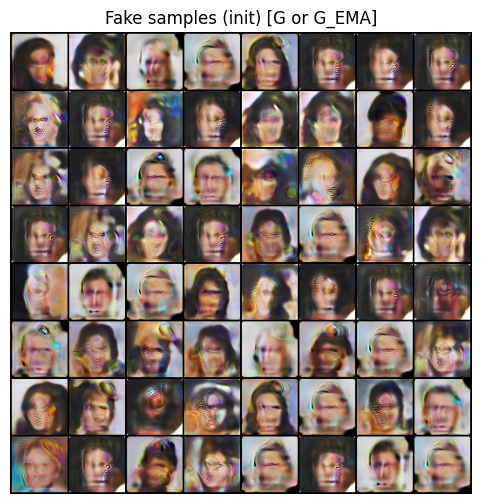

[Epoch 026] loss_D=0.4760 (EMA 0.4760) | loss_G=1.4882 (EMA 1.4882) | D(real)=1.349 | D(fake)=-1.466 | ||∇G||=0.642 | ||∇D||=1.373 | ||θ_G||=4012.9 | ||θ_D||=788.5 | batches=3166 | time=436.2s
[Epoch 027] loss_D=0.4772 (EMA 0.4760) | loss_G=1.5246 (EMA 1.4889) | D(real)=1.338 | D(fake)=-1.499 | ||∇G||=0.668 | ||∇D||=1.458 | ||θ_G||=4020.2 | ||θ_D||=804.2 | batches=3166 | time=434.9s
[Epoch 028] loss_D=0.4704 (EMA 0.4759) | loss_G=1.5423 (EMA 1.4900) | D(real)=1.344 | D(fake)=-1.515 | ||∇G||=0.663 | ||∇D||=1.504 | ||θ_G||=4019.8 | ||θ_D||=819.5 | batches=3166 | time=435.2s
[Epoch 029] loss_D=0.4600 (EMA 0.4756) | loss_G=1.5420 (EMA 1.4910) | D(real)=1.357 | D(fake)=-1.515 | ||∇G||=0.655 | ||∇D||=1.533 | ||θ_G||=4028.0 | ||θ_D||=834.4 | batches=3166 | time=435.6s
[Epoch 030] loss_D=0.4515 (EMA 0.4751) | loss_G=1.5367 (EMA 1.4919) | D(real)=1.370 | D(fake)=-1.511 | ||∇G||=0.680 | ||∇D||=1.573 | ||θ_G||=4036.5 | ||θ_D||=848.9 | batches=3166 | time=436.3s
[Epoch 031] loss_D=0.4615 (EMA 0.47

In [18]:
history4, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=10, gamma=24,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=1, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9995,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.38,
    start_epoch=start_epoch,
    base_global_step=base_global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True , fixed_z= fixed_z
)

In [19]:
ckpt4 = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt4, "stylegan64_celeba_pt4.pt")

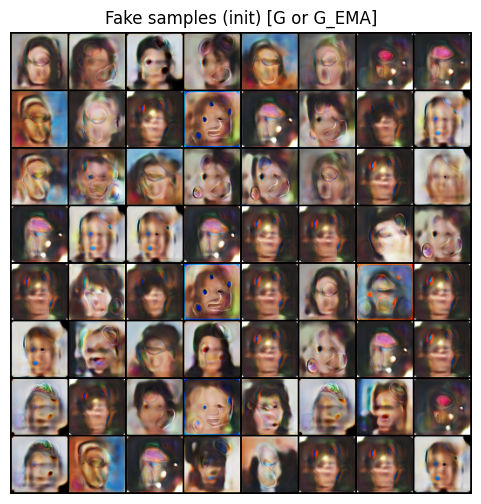

[Epoch 036] loss_D=0.4855 (EMA 0.4855) | loss_G=1.4843 (EMA 1.4843) | D(real)=1.330 | D(fake)=-1.462 | ||∇G||=0.590 | ||∇D||=1.498 | ||θ_G||=4069.4 | ||θ_D||=931.2 | batches=3166 | time=435.8s
[Epoch 037] loss_D=0.4866 (EMA 0.4855) | loss_G=1.4876 (EMA 1.4844) | D(real)=1.336 | D(fake)=-1.463 | ||∇G||=0.620 | ||∇D||=1.521 | ||θ_G||=4074.0 | ||θ_D||=943.8 | batches=3166 | time=436.1s
[Epoch 038] loss_D=0.4739 (EMA 0.4853) | loss_G=1.4983 (EMA 1.4846) | D(real)=1.336 | D(fake)=-1.476 | ||∇G||=0.633 | ||∇D||=1.586 | ||θ_G||=4078.5 | ||θ_D||=956.6 | batches=3166 | time=435.6s
[Epoch 039] loss_D=0.4666 (EMA 0.4849) | loss_G=1.5006 (EMA 1.4850) | D(real)=1.342 | D(fake)=-1.478 | ||∇G||=0.645 | ||∇D||=1.641 | ||θ_G||=4083.0 | ||θ_D||=968.9 | batches=3166 | time=436.0s
[Epoch 040] loss_D=0.4485 (EMA 0.4842) | loss_G=1.5136 (EMA 1.4855) | D(real)=1.351 | D(fake)=-1.491 | ||∇G||=0.638 | ||∇D||=1.715 | ||θ_G||=4085.4 | ||θ_D||=980.8 | batches=3166 | time=436.4s


In [22]:
history5a, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=5, gamma=28,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9995,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.35,
    start_epoch=36, base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True, fixed_z=fixed_z
)

In [23]:
ckpt5a = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt5a, "stylegan64_celeba_pt5a.pt")

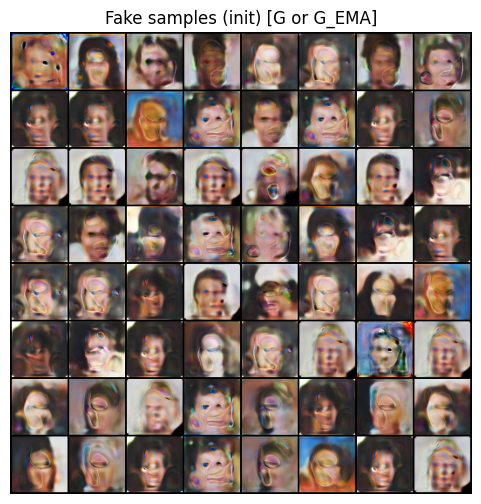

[Epoch 041] loss_D=0.4703 (EMA 0.4703) | loss_G=1.4760 (EMA 1.4760) | D(real)=1.319 | D(fake)=-1.452 | ||∇G||=0.611 | ||∇D||=1.670 | ||θ_G||=4088.3 | ||θ_D||=993.2 | batches=3166 | time=434.5s
[Epoch 042] loss_D=0.4688 (EMA 0.4702) | loss_G=1.4421 (EMA 1.4754) | D(real)=1.333 | D(fake)=-1.421 | ||∇G||=0.586 | ||∇D||=1.610 | ||θ_G||=4091.3 | ||θ_D||=1005.3 | batches=3166 | time=434.9s
[Epoch 043] loss_D=0.4652 (EMA 0.4701) | loss_G=1.4577 (EMA 1.4750) | D(real)=1.346 | D(fake)=-1.434 | ||∇G||=0.595 | ||∇D||=1.612 | ||θ_G||=4097.6 | ||θ_D||=1016.9 | batches=3166 | time=434.9s
[Epoch 044] loss_D=0.4693 (EMA 0.4701) | loss_G=1.4411 (EMA 1.4743) | D(real)=1.351 | D(fake)=-1.421 | ||∇G||=0.588 | ||∇D||=1.537 | ||θ_G||=4099.4 | ||θ_D||=1028.7 | batches=3166 | time=434.2s
[Epoch 045] loss_D=0.4648 (EMA 0.4700) | loss_G=1.4324 (EMA 1.4735) | D(real)=1.355 | D(fake)=-1.413 | ||∇G||=0.606 | ||∇D||=1.509 | ||θ_G||=4106.4 | ||θ_D||=1040.3 | batches=3166 | time=435.6s


In [25]:
history5b, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=5, gamma=30,          # ↑ R1 (o 28 si venías en 24)
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9997,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.30,
    start_epoch=41, base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True, noise_clip_value=0.4 ,     #  [-0.4,0.4]
    fixed_z=fixed_z
)

In [26]:
ckpt5b = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt5b, "stylegan64_celeba_pt5b.pt")

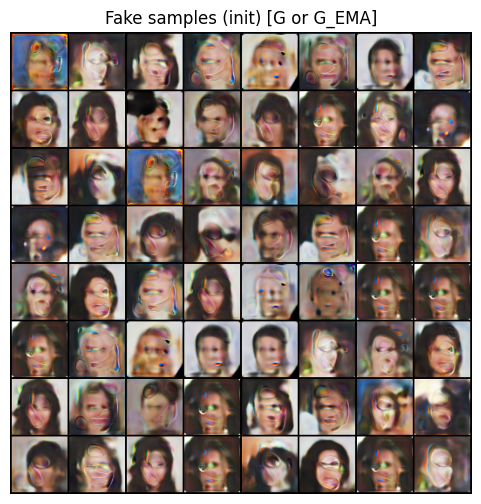

[Epoch 046] loss_D=0.4597 (EMA 0.4597) | loss_G=1.4477 (EMA 1.4477) | D(real)=1.358 | D(fake)=-1.426 | ||∇G||=0.631 | ||∇D||=1.501 | ||θ_G||=4113.1 | ||θ_D||=1051.8 | batches=3166 | time=434.0s
[Epoch 047] loss_D=0.4614 (EMA 0.4597) | loss_G=1.4410 (EMA 1.4476) | D(real)=1.356 | D(fake)=-1.420 | ||∇G||=0.626 | ||∇D||=1.480 | ||θ_G||=4120.0 | ||θ_D||=1063.2 | batches=3166 | time=434.7s
[Epoch 048] loss_D=0.4604 (EMA 0.4598) | loss_G=1.4433 (EMA 1.4475) | D(real)=1.361 | D(fake)=-1.423 | ||∇G||=0.654 | ||∇D||=1.485 | ||θ_G||=4123.3 | ||θ_D||=1073.8 | batches=3166 | time=433.9s
[Epoch 049] loss_D=0.4560 (EMA 0.4597) | loss_G=1.4544 (EMA 1.4476) | D(real)=1.354 | D(fake)=-1.433 | ||∇G||=0.661 | ||∇D||=1.489 | ||θ_G||=4129.5 | ||θ_D||=1084.5 | batches=3166 | time=435.4s
[Epoch 050] loss_D=0.4435 (EMA 0.4594) | loss_G=1.4610 (EMA 1.4479) | D(real)=1.350 | D(fake)=-1.440 | ||∇G||=0.663 | ||∇D||=1.503 | ||θ_G||=4134.3 | ||θ_D||=1095.4 | batches=3166 | time=438.8s
[Epoch 051] loss_D=0.4658 (EMA

In [27]:
history6, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=8, gamma=30,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True, disc_steps=1,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9997,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.32,
    start_epoch=46, base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True, noise_clip_value=0.4 ,     #  [-0.4,0.4]
    fixed_z=fixed_z
)

In [32]:
ckpt6 = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt6, "stylegan64_celeba_pt6.pt")

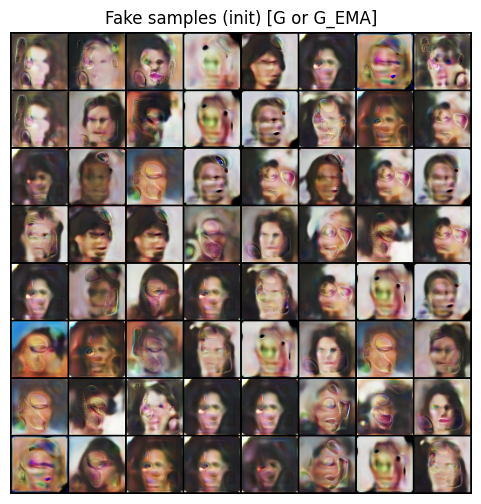

[Epoch 054] loss_D=0.2732 (EMA 0.2732) | loss_G=1.3929 (EMA 1.3929) | D(real)=1.366 | D(fake)=-1.445 | ||∇G||=0.656 | ||∇D||=1.542 | ||θ_G||=4161.3 | ||θ_D||=1148.4 | batches=3166 | time=672.5s
[Epoch 055] loss_D=0.2731 (EMA 0.2732) | loss_G=1.3801 (EMA 1.3926) | D(real)=1.370 | D(fake)=-1.431 | ||∇G||=0.657 | ||∇D||=1.568 | ||θ_G||=4167.5 | ||θ_D||=1170.0 | batches=3166 | time=673.0s
[Epoch 056] loss_D=0.2850 (EMA 0.2735) | loss_G=1.3823 (EMA 1.3924) | D(real)=1.390 | D(fake)=-1.430 | ||∇G||=0.700 | ||∇D||=1.563 | ||θ_G||=4170.3 | ||θ_D||=1190.9 | batches=3166 | time=673.1s
[Epoch 056] ↓ lr_D x0.80 -> 5.60e-04


In [52]:
history7a, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=3, gamma=30,
    monitor_img=2, monitor_loss=1,
    train_gen=1, hinge=True,
    disc_steps=2,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9997,
    use_diffaug=True, r1_every=8,
    use_softplus=False,
    style_mixing_prob=0.28,
    start_epoch=54, base_global_step=global_step,
    gen_ema=gen_ema, lr_Disc_decay=True,
    control_noise=True, noise_clip_value=0.40,
    fixed_z=fixed_z)


In [54]:
ckpt7a = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt6, "stylegan64_celeba_pt7.pt")

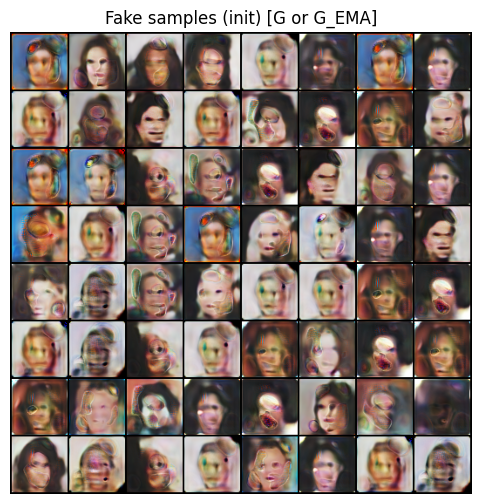

[Epoch 057] loss_D=0.4248 (EMA 0.4248) | loss_G=1.4699 (EMA 1.4699) | D(real)=1.394 | D(fake)=-1.449 | ||∇G||=0.639 | ||∇D||=1.677 | ||θ_G||=4174.5 | ||θ_D||=1197.3 | batches=3166 | time=432.9s
[Epoch 058] loss_D=0.4056 (EMA 0.4244) | loss_G=1.4752 (EMA 1.4700) | D(real)=1.383 | D(fake)=-1.453 | ||∇G||=0.649 | ||∇D||=1.758 | ||θ_G||=4182.7 | ||θ_D||=1203.9 | batches=3166 | time=433.8s
[Epoch 059] loss_D=0.4100 (EMA 0.4241) | loss_G=1.4379 (EMA 1.4694) | D(real)=1.408 | D(fake)=-1.415 | ||∇G||=0.615 | ||∇D||=1.737 | ||θ_G||=4194.1 | ||θ_D||=1210.3 | batches=3166 | time=434.5s
[Epoch 060] loss_D=0.4114 (EMA 0.4238) | loss_G=1.4639 (EMA 1.4693) | D(real)=1.393 | D(fake)=-1.445 | ||∇G||=0.642 | ||∇D||=1.769 | ||θ_G||=4202.9 | ||θ_D||=1217.1 | batches=3166 | time=434.8s


In [55]:
for pg in optimizerG.param_groups:
    pg['lr'] *= 1.15

history7b, gen_ema, fixed_z, global_step, last_epoch = train_gan(
    train_loader=train_loader,
    generador=G, discriminador=D,
    optimizerG=optimizerG, optimizerD=optimizerD,
    criterion=criterion,
    latent_dim=512, epochs=4, gamma=30,
    monitor_img=2, monitor_loss=1,
    train_gen=1,
    hinge=True, disc_steps=1,
    g_warmup_epochs=0, g_warmup_train_gen=1,
    use_ema=True, ema_decay=0.9997,
    use_diffaug=True, r1_every=16, use_softplus=False,
    style_mixing_prob=0.35,
    start_epoch=57, base_global_step=global_step,
    gen_ema=gen_ema,
    style_decay=False, lr_Disc_decay=True,
    control_noise=True, noise_clip_value=0.35,
    fixed_z=fixed_z
)

In [56]:
ckpt7b = {
    "G": G.state_dict(),
    "D": D.state_dict(),
    "optG": optimizerG.state_dict(),
    "optD": optimizerD.state_dict(),
    "gen_ema": gen_ema.state_dict() if gen_ema is not None else None,
    "fixed_z": fixed_z.detach().cpu(),
    "global_step": global_step,
    "trained_epochs_total": last_epoch}

torch.save(ckpt7b, "stylegan64_celeba_pt7b.pt")

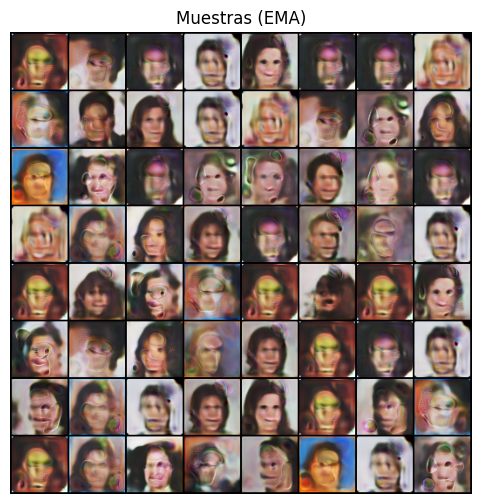

In [59]:
z_dim = 512          # debe coincidir con tu modelo
n = 64            # número de imágenes a generar
rows = 8           # columnas del grid

imgs = sample_with_ema(
    G,
    gen_ema=gen_ema,
    z=None,
    z_dim=z_dim,
    n=n,
    rows=rows,
    out_path=None,           # None => no guarda, solo retorna el tensor [0,1]
    assume_logits=True,      # True si tu G devuelve logits en R; False si ya devuelve en [-1,1] (tanh)
    style_mixing_prob=0.2,   # p de style mixing (si tu G lo soporta)
    truncation=0.8   # en tu firma actual es un flag booleano, no fuerza
)

show_grid(imgs, rows=rows, title="Muestras (EMA)" if gen_ema is not None else "Muestras (G)")


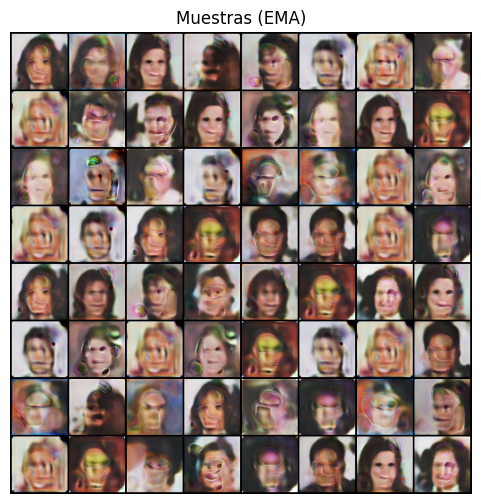

In [61]:
z_dim = 512          # debe coincidir con tu modelo
n = 64            # número de imágenes a generar
rows = 8           # columnas del grid

imgs = sample_with_ema(
    G,
    gen_ema=gen_ema,
    z=None,
    z_dim=z_dim,
    n=n,
    rows=rows,
    out_path=None,           # None => no guarda, solo retorna el tensor [0,1]
    assume_logits=True,      # True si tu G devuelve logits en R; False si ya devuelve en [-1,1] (tanh)
    style_mixing_prob=0.2,   # p de style mixing (si tu G lo soporta)
    truncation=0.37   # en tu firma actual es un flag booleano, no fuerza
)

show_grid(imgs, rows=rows, title="Muestras (EMA)" if gen_ema is not None else "Muestras (G)")

---

In [ ]:
import shutil

origen = "/content/stylegan64_celeba_pt2.pt"
destino = "/content/drive/MyDrive/stylegan64_celeba_pt2.pt"

shutil.move(origen, destino)

'/content/drive/MyDrive/stylegan64_celeba_pt2.pt'